# Implementation Of Automatic Wiper Speed Control And Headlight Modes Control Systems Using Fuzzy Logic

In [1]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

## A.) Automatic Wiper Speed

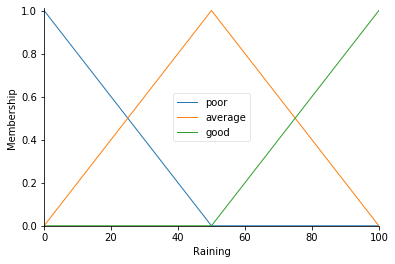

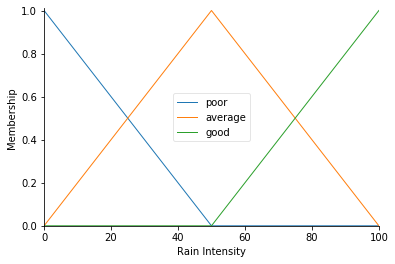

In [3]:
import numpy as np
import matplotlib.pyplot as plt

raining=ctrl.Antecedent(np.arange(0,101,1),'Raining')
# raining['poor']=fuzzy.trimf(raining.universe,[0,0,40])
# raining['average']=fuzzy.trapmf(raining.universe,[30,40,60,70])
# raining['good']=fuzzy.trimf(raining.universe,[80,90,100])

rain_intensity=ctrl.Antecedent(np.arange(0,101,1),'Rain Intensity')
# rain_intensity['poor']=fuzzy.trimf(rain_intensity.universe,[0,0,40])
# rain_intensity['average']=fuzzy.trapmf(rain_intensity.universe,[40,50,70,80])
# rain_intensity['good']=fuzzy.trimf(rain_intensity.universe,[70,90,100])

raining.automf(3)
rain_intensity.automf(3)

raining.view()
rain_intensity.view()

plt.show()

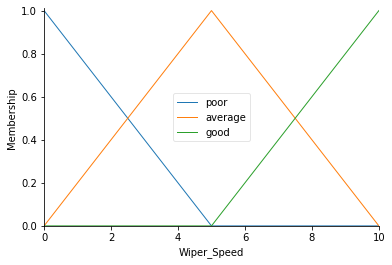

In [4]:
wiper_speed=ctrl.Consequent(np.arange(0,11,1),'Wiper_Speed')
wiper_speed.automf(3)

wiper_speed.view()

plt.show()

The automated value of the voltage for the wiper speed is 5.000000000000001


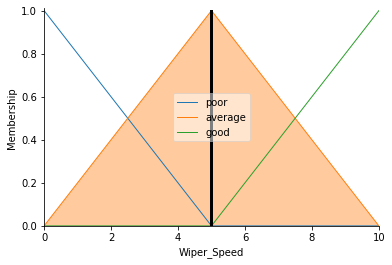

In [5]:
rule1 = ctrl.Rule(raining['poor'] | rain_intensity['poor'], wiper_speed['poor'])
rule2 = ctrl.Rule(rain_intensity['average'], wiper_speed['average'])
rule3 = ctrl.Rule(rain_intensity['good'] | raining['good'], wiper_speed['good'])

rules=[rule1,rule2,rule3]
tipping=ctrl.ControlSystem(rules)
Tip=ctrl.ControlSystemSimulation(tipping)

Tip.input['Raining'] = 50
Tip.input['Rain Intensity'] = 50
Tip.compute()

print('The automated value of the voltage for the wiper speed is', Tip.output['Wiper_Speed'])

wiper_speed.view(sim=Tip)

## B.) Headlight Modes

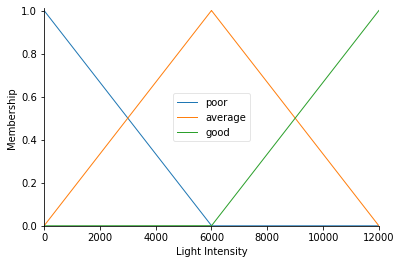

In [6]:
lightintensity=ctrl.Antecedent(np.arange(0,12001,1),'Light Intensity')

lightintensity.automf(3)
lightintensity.view()


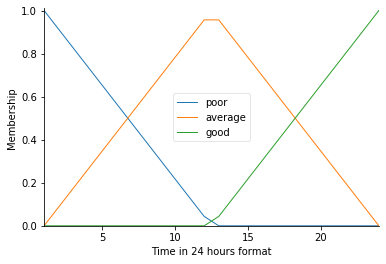

In [7]:
headlight=ctrl.Antecedent(np.arange(1,25,1),'Time in 24 hours format')

headlight.automf(3)
headlight.view()

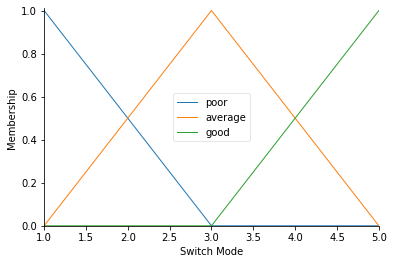

In [8]:
switch=ctrl.Consequent(np.arange(1,6,1),'Switch Mode')
switch.automf(3)
switch.view()
plt.show()

In [9]:
from datetime import datetime
now = datetime.now()
currentHour = now.hour
print('The time (in 24 hour format) is', currentHour)

The time (in 24 hour format) is 18


The automated value of the switch mode is 3.3284109842489737


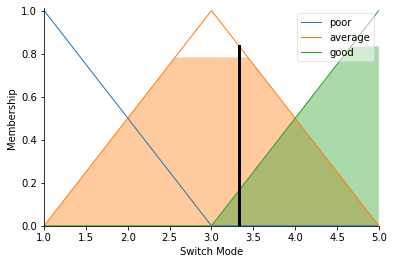

In [10]:
rule1 = ctrl.Rule(lightintensity['poor'] | headlight['poor'], switch['poor'])
rule2 = ctrl.Rule(headlight['average'], switch['average'])
rule3 = ctrl.Rule(headlight['good'] | lightintensity['good'], switch['good'])

rules=[rule1,rule2,rule3]
tipping=ctrl.ControlSystem(rules)
tip=ctrl.ControlSystemSimulation(tipping)

tip.input['Light Intensity']= 11000
tip.input['Time in 24 hours format']= 15
tip.compute()

print('The automated value of the switch mode is', tip.output['Switch Mode'])

switch.view(sim=tip)